# ЛР 02. Разведочный анализ данных

Файл `data/LR2/StudentPerformanceFactors.csv` — таблица факторов успеваемости школьников.

**Формат:** CSV, запятая, десятичная точка, UTF-8. Строка — один ученик.

**Целевая переменная:** `Exam_Score` — балл экзамена.

| Столбец | Содержание |
|---|---|
| `Hours_Studied` | часы занятий |
| `Attendance` | посещаемость |
| `Parental_Involvement` | участие родителей: Low / Medium / High |
| `Access_to_Resources` | доступ к учебным ресурсам |
| `Extracurricular_Activities` | внеучебные занятия: Yes / No |
| `Sleep_Hours` | часы сна |
| `Previous_Scores` | предыдущие оценки |
| `Motivation_Level` | мотивация |
| `Internet_Access` | доступ в интернет |
| `Tutoring_Sessions` | число занятий с репетитором |
| `Family_Income` | доход семьи |
| `Teacher_Quality` | качество преподавания |
| `School_Type` | тип школы: Public / Private |
| `Peer_Influence` | влияние сверстников |
| `Physical_Activity` | физическая активность |
| `Learning_Disabilities` | трудности в обучении |
| `Parental_Education_Level` | образование родителей |
| `Distance_from_Home` | расстояние от дома до школы |
| `Gender` | пол |
| `Exam_Score` | балл экзамена |


**1.** Импортировать датасет

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG = Path("figures")
FIG.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("/content/StudentPerformanceFactors.csv")
df = pd.read_csv(DATA_PATH)
print("Строк:", df.shape[0], "столбцов:", df.shape[1])
df.head()

Строк: 6607 столбцов: 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


**2.** Проверить данные на пропуски и наличие аномальных значений. Заполнить пропуски и устранить выбросы. Проверить графически, что пропуски и аномальные значения обработаны.

**Пропуск** — ячейка без наблюдения. `isna()` строит маску той же формы. `sum()` — число пропусков по столбцам, `sum().sum()` — всего пустых ячеек, `any(axis=1).sum()` — число строк, где есть хотя бы один пропуск. Доля — отношение числа пропусков в столбце к числу строк.

In [5]:
missing = df.isna().sum()
missing_share = missing / len(df)
print(pd.DataFrame({"пропусков": missing, "доля": missing_share.round(4)}))
print("Всего пропущенных ячеек:", int(df.isna().sum().sum()))
print("Строк с хотя бы одним пропуском:", int(df.isna().any(axis=1).sum()))


                            пропусков    доля
Hours_Studied                       0  0.0000
Attendance                          0  0.0000
Parental_Involvement                0  0.0000
Access_to_Resources                 0  0.0000
Extracurricular_Activities          0  0.0000
Sleep_Hours                         0  0.0000
Previous_Scores                     0  0.0000
Motivation_Level                    0  0.0000
Internet_Access                     0  0.0000
Tutoring_Sessions                   0  0.0000
Family_Income                       0  0.0000
Teacher_Quality                    78  0.0118
School_Type                         0  0.0000
Peer_Influence                      0  0.0000
Physical_Activity                   0  0.0000
Learning_Disabilities               0  0.0000
Parental_Education_Level           90  0.0136
Distance_from_Home                 67  0.0101
Gender                              0  0.0000
Exam_Score                          0  0.0000
Всего пропущенных ячеек: 235
Строк

**Тепловая карта пропусков** — та же таблица в виде 1 (пропуск) и 0 (значение есть).

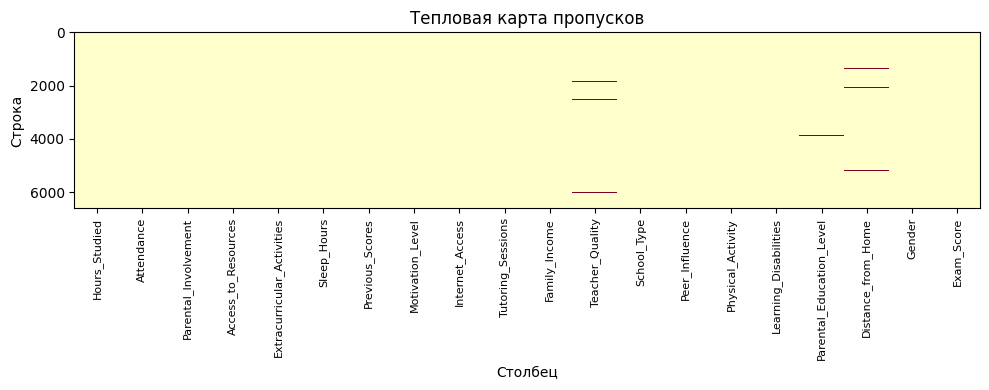

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(df.isna().astype(int).values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1, interpolation="nearest")
ax.set_title("Тепловая карта пропусков")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")
ax.set_xticks(range(df.shape[1]))
ax.set_xticklabels(df.columns, rotation=90, fontsize=8)
plt.tight_layout()
fig.savefig(FIG / "01_missing_heatmap.png", dpi=120)
plt.show()


**Среднее** — сумма, делённая на число значений. **Медиана** — середина упорядоченного ряда. **СКО** — корень из дисперсии. **IQR** — `Q3 − Q1`, ширина центральных 50 %.

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
stats = df[numeric_cols].describe().T
stats["median"] = df[numeric_cols].median()
stats["IQR"] = stats["75%"] - stats["25%"]
stats.round(3)


,count,mean,std,min,25%,50%,75%,max,median,IQR
Hours_Studied,6607.0,19.975,5.991,1.0,16.0,20.0,24.0,44.0,20.0,8.0
Attendance,6607.0,79.977,11.547,60.0,70.0,80.0,90.0,100.0,80.0,20.0
Sleep_Hours,6607.0,7.029,1.468,4.0,6.0,7.0,8.0,10.0,7.0,2.0
Previous_Scores,6607.0,75.071,14.400,50.0,63.0,75.0,88.0,100.0,75.0,25.0
Tutoring_Sessions,6607.0,1.494,1.231,0.0,1.0,1.0,2.0,8.0,1.0,1.0
Physical_Activity,6607.0,2.968,1.031,0.0,2.0,3.0,4.0,6.0,3.0,2.0
Exam_Score,6607.0,67.236,3.890,55.0,65.0,67.0,69.0,101.0,67.0,4.0


Гистограмма показывает, сколько учеников попало в каждый интервал. Диаграмма размаха сжимает столбец: ящик от Q1 до Q3, черта внутри — медиана, точки за усами — кандидаты в выбросы.

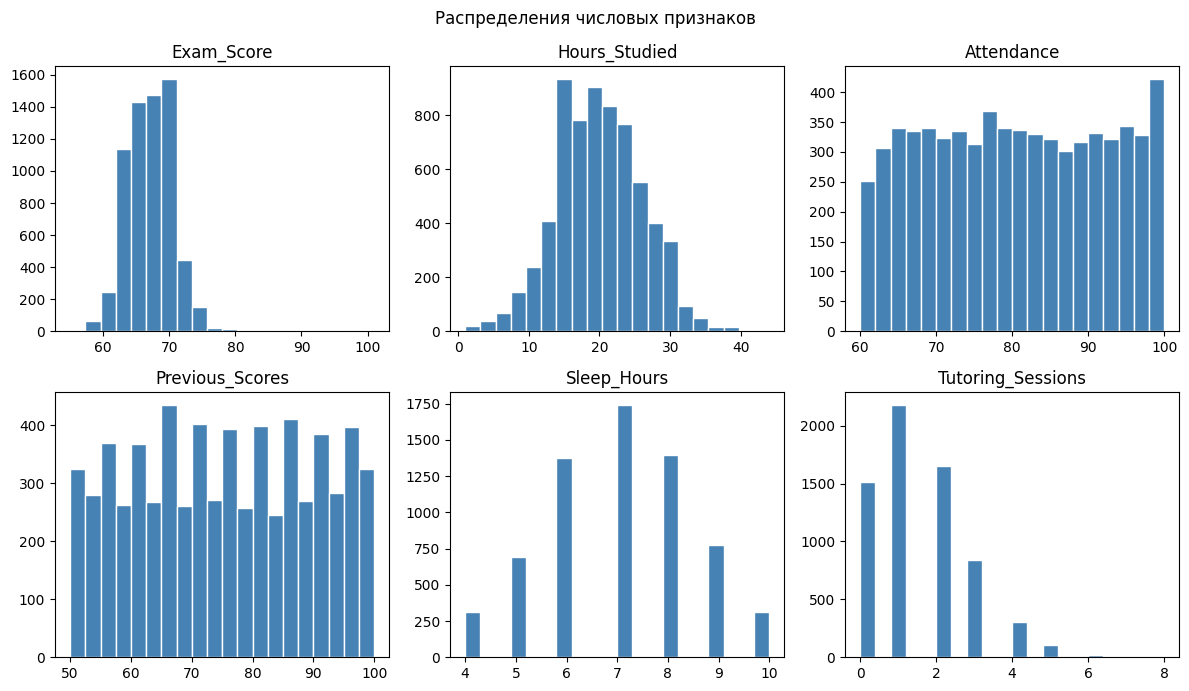

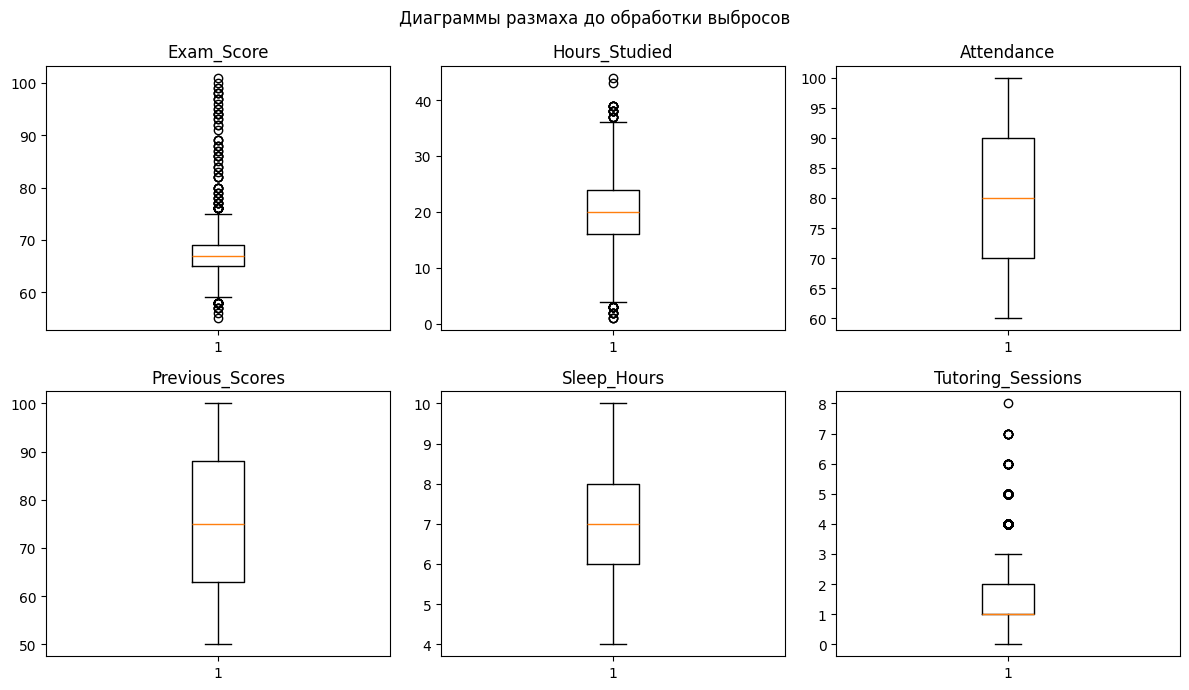

In [8]:
plot_cols = ["Exam_Score", "Hours_Studied", "Attendance", "Previous_Scores", "Sleep_Hours", "Tutoring_Sessions"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df[col], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Распределения числовых признаков")
plt.tight_layout()
fig.savefig(FIG / "02_histograms.png", dpi=120)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.boxplot(df[col].dropna(), orientation="vertical")
    ax.set_title(col)
plt.suptitle("Диаграммы размаха до обработки выбросов")
plt.tight_layout()
fig.savefig(FIG / "03_boxplot_before.png", dpi=120)
plt.show()


**Проверка аномальных значений и выбросов.** Для статистического выявления потенциальных выбросов используется межквартильный размах (IQR). Значения, находящиеся за пределами `[Q1 − 1,5·IQR; Q3 + 1,5·IQR]`, рассматриваются как потенциальные статистические выбросы. После этого выполняется проверка допустимости значений с учётом смысла признака. Таким образом, статистически редкое значение не считается ошибочным автоматически. Исправляются только явно аномальные значения. Пропуски в категориальных столбцах заполняются модой.


In [9]:
df_clean = df.copy()

cat_missing = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in cat_missing:
    mode = df_clean[col].mode().iloc[0]
    n_na = int(df_clean[col].isna().sum())

    df_clean[col] = df_clean[col].fillna(mode)

    print(f"{col}: пропусков {n_na}, мода «{mode}»")


print("\nПотенциальные статистические выбросы по IQR:")

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    mask = (df_clean[col] < low) | (df_clean[col] > high)

    print(
        f"{col}: "
        f"границы [{low:.3f}; {high:.3f}], "
        f"кандидатов в выбросы: {int(mask.sum())}"
    )


print("\nПроверка допустимых диапазонов:")

mask_attendance = (
    (df_clean["Attendance"] < 0) |
    (df_clean["Attendance"] > 100)
)
print("Attendance:", int(mask_attendance.sum()))

mask_previous = (
    (df_clean["Previous_Scores"] < 0) |
    (df_clean["Previous_Scores"] > 100)
)
print("Previous_Scores:", int(mask_previous.sum()))

mask_exam = (
    (df_clean["Exam_Score"] < 0) |
    (df_clean["Exam_Score"] > 100)
)
print("Exam_Score:", int(mask_exam.sum()))


exam_median = df_clean["Exam_Score"].median()

df_clean.loc[mask_exam, "Exam_Score"] = exam_median

print(
    f"\nИсправлено аномальных значений Exam_Score: "
    f"{int(mask_exam.sum())}"
)
print(f"Использованная медиана Exam_Score: {exam_median:.3f}")


print("\nСтрок после обработки:", len(df_clean))
print(
    "Пропущенных ячеек после обработки:",
    int(df_clean.isna().sum().sum())
)




Teacher_Quality: пропусков 78, мода «Medium»
Parental_Education_Level: пропусков 90, мода «High School»
Distance_from_Home: пропусков 67, мода «Near»

Потенциальные статистические выбросы по IQR:
Hours_Studied: границы [4.000; 36.000], кандидатов в выбросы: 43
Attendance: границы [40.000; 120.000], кандидатов в выбросы: 0
Sleep_Hours: границы [3.000; 11.000], кандидатов в выбросы: 0
Previous_Scores: границы [25.500; 125.500], кандидатов в выбросы: 0
Tutoring_Sessions: границы [-0.500; 3.500], кандидатов в выбросы: 430
Physical_Activity: границы [-1.000; 7.000], кандидатов в выбросы: 0
Exam_Score: границы [59.000; 75.000], кандидатов в выбросы: 104

Проверка допустимых диапазонов:
Attendance: 0
Previous_Scores: 0
Exam_Score: 1

Исправлено аномальных значений Exam_Score: 1
Использованная медиана Exam_Score: 67.000

Строк после обработки: 6607
Пропущенных ячеек после обработки: 0


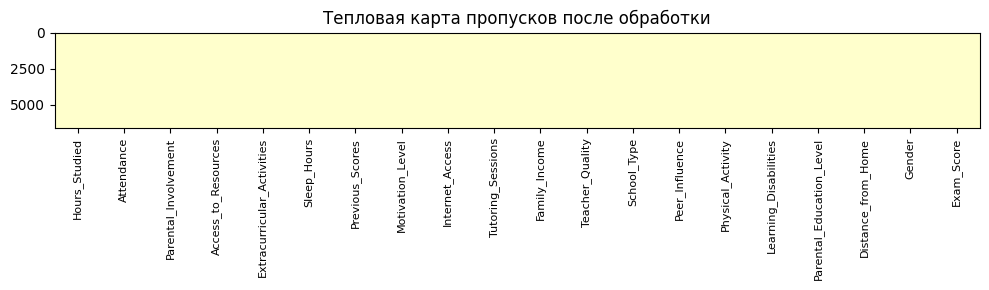

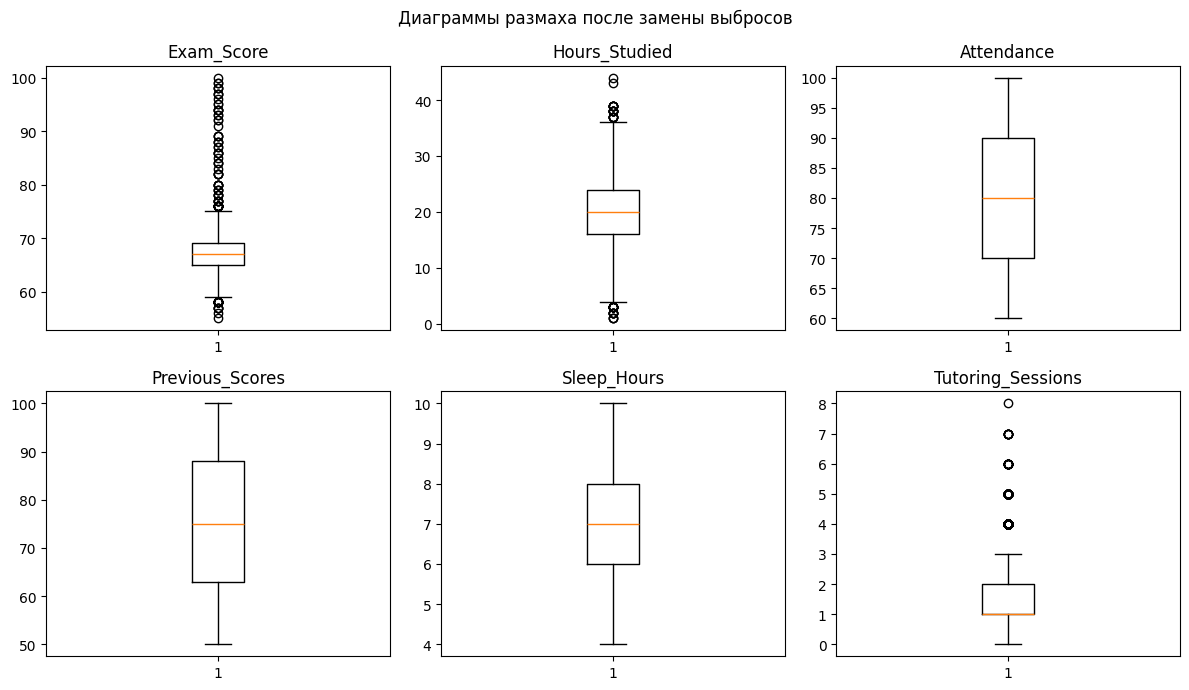

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(df_clean.isna().astype(int).values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1, interpolation="nearest")
ax.set_title("Тепловая карта пропусков после обработки")
ax.set_xticks(range(df_clean.shape[1]))
ax.set_xticklabels(df_clean.columns, rotation=90, fontsize=8)
plt.tight_layout()
fig.savefig(FIG / "04_missing_after.png", dpi=120)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.boxplot(df_clean[col], orientation="vertical")
    ax.set_title(col)
plt.suptitle("Диаграммы размаха после замены выбросов")
plt.tight_layout()
fig.savefig(FIG / "05_boxplot_after.png", dpi=120)
plt.show()


**Коэффициент Пирсона** — мера линейной связи двух числовых признаков от −1 до 1. Тепловая карта собирает все такие коэффициенты в одну таблицу: цвет кодирует знак и силу.

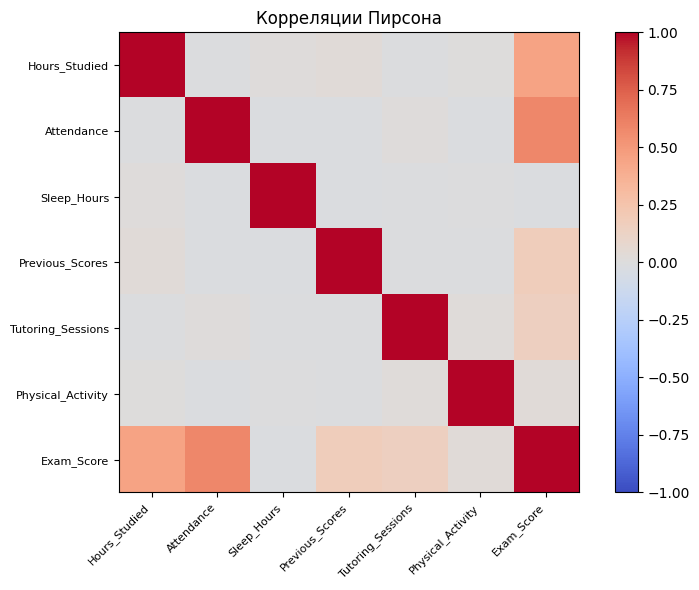

Exam_Score           1.000
Attendance           0.582
Hours_Studied        0.446
Previous_Scores      0.174
Tutoring_Sessions    0.154
Physical_Activity    0.028
Sleep_Hours         -0.016
Name: Exam_Score, dtype: float64


In [11]:
corr = df_clean[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
ax.set_title("Корреляции Пирсона")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(FIG / "06_correlation.png", dpi=120)
plt.show()
print(corr["Exam_Score"].sort_values(key=lambda s: s.abs(), ascending=False).round(3))


**3.** Сгенерировать новые признаки (не менее двух) и закодировать категориальные признаки.

`study_per_sleep` — часы занятий на один час сна. `study_attendance` — часы занятий с учётом посещаемости. Уровни Low / Medium / High и расстояние до школы имеют порядок, их заменяют числами. Метки из двух значений переводят в 0/1. У влияния сверстников порядка нет, для него строят индикаторы.

In [12]:
df_feat = df_clean.copy()
df_feat["study_per_sleep"] = df_feat["Hours_Studied"] / df_feat["Sleep_Hours"]
df_feat["study_attendance"] = df_feat["Hours_Studied"] * df_feat["Attendance"] / 100
df_feat[["Hours_Studied", "Sleep_Hours", "Attendance", "study_per_sleep", "study_attendance"]].head()


,Hours_Studied,Sleep_Hours,Attendance,study_per_sleep,study_attendance
0,23,7,84,3.285714,19.32
1,19,8,64,2.375000,12.16
2,24,7,98,3.428571,23.52
3,29,8,89,3.625000,25.81
4,19,6,92,3.166667,17.48


In [13]:
df_enc = df_feat.copy()
level = {"Low": 1, "Medium": 2, "High": 3}
for col in ["Parental_Involvement", "Access_to_Resources", "Motivation_Level", "Family_Income", "Teacher_Quality"]:
    df_enc[col + "_ord"] = df_enc[col].map(level)
df_enc["parent_edu_ord"] = df_enc["Parental_Education_Level"].map({"High School": 1, "College": 2, "Postgraduate": 3})
df_enc["distance_ord"] = df_enc["Distance_from_Home"].map({"Near": 1, "Moderate": 2, "Far": 3})
df_enc["extra_yes"] = (df_enc["Extracurricular_Activities"] == "Yes").astype(int)
df_enc["internet_yes"] = (df_enc["Internet_Access"] == "Yes").astype(int)
df_enc["private_school"] = (df_enc["School_Type"] == "Private").astype(int)
df_enc["learning_disability"] = (df_enc["Learning_Disabilities"] == "Yes").astype(int)
df_enc["gender_male"] = (df_enc["Gender"] == "Male").astype(int)

df_ohe = pd.get_dummies(df_enc, columns=["Peer_Influence"], drop_first=True, dtype=int)
text_cols = [
    "Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities",
    "Motivation_Level", "Internet_Access", "Family_Income", "Teacher_Quality",
    "School_Type", "Learning_Disabilities", "Parental_Education_Level",
    "Distance_from_Home", "Gender",
]
df_ohe = df_ohe.drop(columns=text_cols)
print("Размер после кодирования:", df_ohe.shape)
print("Столбцов было", df.shape[1], ", индикаторов сверстников", df_ohe.filter(like="Peer_Influence").shape[1])
df_ohe.head()


Размер после кодирования: (6607, 23)
Столбцов было 20 , индикаторов сверстников 2


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,study_per_sleep,study_attendance,Parental_Involvement_ord,...,Teacher_Quality_ord,parent_edu_ord,distance_ord,extra_yes,internet_yes,private_school,learning_disability,gender_male,Peer_Influence_Neutral,Peer_Influence_Positive
0,23,84,7,73,0,3,67,3.285714,19.32,1,...,2,1,1,0,1,0,0,1,0,1
1,19,64,8,59,2,4,61,2.375000,12.16,1,...,2,2,2,0,1,0,0,0,0,0
2,24,98,7,91,2,4,74,3.428571,23.52,2,...,2,3,1,1,1,0,0,1,1,0
3,29,89,8,98,1,4,71,3.625000,25.81,1,...,2,1,2,1,1,0,0,1,0,0
4,19,92,6,65,3,4,70,3.166667,17.48,2,...,3,2,1,1,1,0,0,0,1,0


**4.** Выполнить стандартизацию и нормализацию.

Min–max преобразование приводит значения числовых признаков к диапазону `[0, 1]`. Z-score стандартизация приводит среднее значение признака к 0 и стандартное отклонение к 1. Масштабирование применяется к признакам, используемым для анализа, а целевая переменная `Exam_Score` не включается в набор масштабируемых признаков.


In [15]:
scale_cols = [c for c in df_ohe.columns if pd.api.types.is_numeric_dtype(df_ohe[c])]
df_minmax = df_ohe.copy()
df_std = df_ohe.copy()
show = ["Hours_Studied", "Attendance", "Previous_Scores", "Sleep_Hours", "study_per_sleep"]

print("Нормализация min-max:")
for col in scale_cols:
    series = df_ohe[col].astype(float)
    xmin, xmax = series.min(), series.max()
    df_minmax[col] = 0.0 if xmax == xmin else (series - xmin) / (xmax - xmin)
print(df_minmax[show].agg(["min", "max"]).T)

print("\nСтандартизация z-score:")
for col in scale_cols:
    series = df_ohe[col].astype(float)
    mu, sigma = series.mean(), series.std(ddof=0)
    df_std[col] = 0.0 if sigma == 0 else (series - mu) / sigma
print(df_std[show].agg(["mean", "std"]).T)


Нормализация min-max:
                 min  max
Hours_Studied    0.0  1.0
Attendance       0.0  1.0
Previous_Scores  0.0  1.0
Sleep_Hours      0.0  1.0
study_per_sleep  0.0  1.0

Стандартизация z-score:
                         mean       std
Hours_Studied   -1.247510e-16  1.000076
Attendance      -2.973590e-16  1.000076
Previous_Scores  1.973431e-16  1.000076
Sleep_Hours     -2.064843e-16  1.000076
study_per_sleep -2.903686e-16  1.000076
